In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("soybean_dataset.csv")

In [3]:
print("Dataset Shape")
print("Number of rows    : ", df.shape[0])
print("Number of columns : ", df.shape[1])

Dataset Shape
Number of rows    :  320
Number of columns :  11


Number of unique cultivars

In [4]:
print("Cultivar Information")
print("Number of unique cultivars :", df['Cultivar'].nunique())


Cultivar Information
Number of unique cultivars : 40


In [5]:
print("Cultivars:")
print(sorted(df['Cultivar'].unique()))

Cultivars:
['74K75RSF CE', '77HO111I2X - GUAPORÉ', '79I81RSF IPRO', '82HO111 IPRO - HO COXIM IPRO', '82I78RSF IPRO', '83IX84RSF I2X', '96R29 IPRO', '97Y97 IPRO', '98R30 CE', 'ADAPTA LTT 8402 IPRO', 'ATAQUE I2X', 'BRASMAX BÔNUS IPRO', 'BRASMAX OLIMPO IPRO', 'ELISA IPRO', 'EXPANDE LTT 8301 IPRO', 'FORTALECE L090183 RR', 'FORTALEZA IPRO', 'FTR 3179 IPRO', 'FTR 3190 IPRO', 'FTR 3868 IPRO', 'FTR 4280 IPRO', 'FTR 4288 IPRO', 'GNS7700 IPRO', 'GNS7900 IPRO - AMPLA', 'LAT 1330BT', 'LTT 7901 IPRO', 'LYNDA IPRO', 'M 8644 IPRO', 'MANU IPRO', 'MONSOY 8330I2X', 'MONSOY M8606I2X', 'NEO 760 CE', 'NEO 790 IPRO', 'NK 7777 IPRO', 'NK 8100 IPRO', 'NK 8770 IPRO', 'PAULA IPRO', 'SUZY IPRO', 'SYN2282IPRO', 'TMG 22X83I2X']


In [6]:
print("Season Information")
print("Number of unique seasons : ",df['Season'].nunique())

Season Information
Number of unique seasons :  2


In [7]:
print("Season values:")
print(sorted(df['Season'].unique()))

Season values:
[np.int64(1), np.int64(2)]


In [8]:
print("Missing Values Per Column")
print(df.isnull().sum())

print("Total Missing Values in Dataset:", df.isnull().sum().sum())

Missing Values Per Column
Season        0
Cultivar      0
Repetition    0
PH            0
IFP           0
NLP           0
NGP           0
NGL           0
NS            0
MHG           0
GY            0
dtype: int64
Total Missing Values in Dataset: 0


Distribution of Soybean Grain Yield

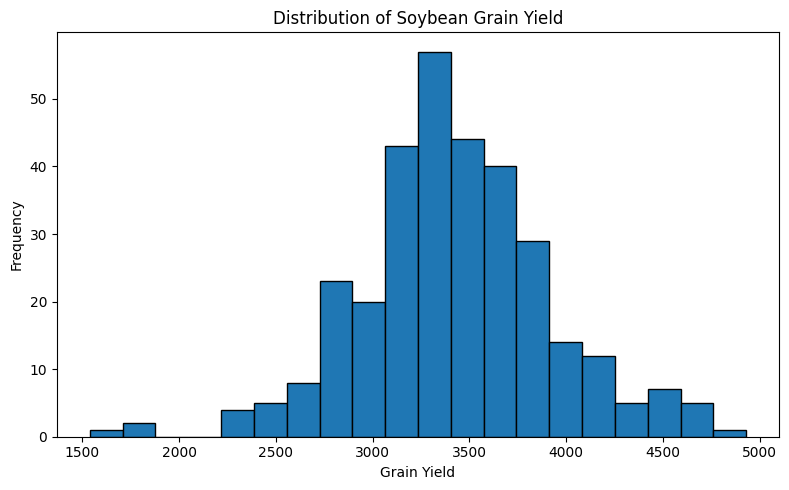

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["GY"], bins=20, edgecolor="black")
plt.xlabel("Grain Yield")
plt.ylabel("Frequency")
plt.title("Distribution of Soybean Grain Yield")
plt.tight_layout()
plt.show()

Grain Yield by Season

<Figure size 800x500 with 0 Axes>

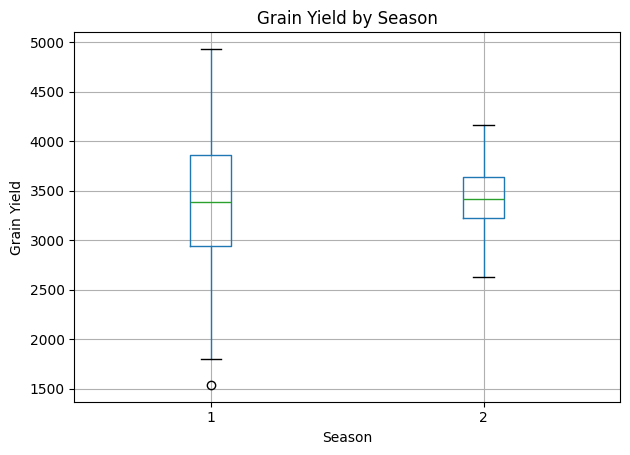

In [12]:
plt.figure(figsize=(8, 5))
df.boxplot(column="GY", by="Season")
plt.xlabel("Season")
plt.ylabel("Grain Yield")
plt.title("Grain Yield by Season")
plt.suptitle("")
plt.tight_layout()
plt.show()

Correlation matrix for numerical variables

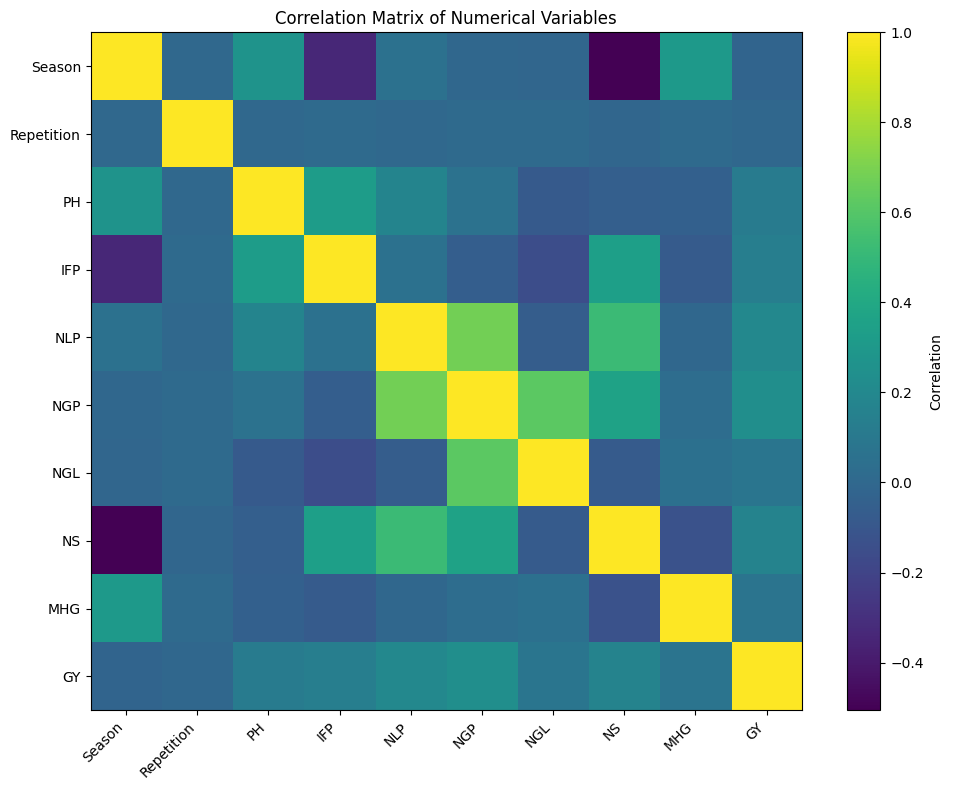

In [13]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

Data Encoding and Scaling

In [15]:
X = df.drop(columns=["GY"])
y = df["GY"]

Convert cultivar into numerical column

In [17]:
X_encoded = pd.get_dummies(X, columns=["Cultivar"],drop_first=False,dtype=int)
print(X_encoded.head())

   Season  Repetition     PH    IFP    NLP     NGP   NGL   NS     MHG  \
0       1           1  58.80  15.20   98.2  177.80  1.81  5.2  152.20   
1       1           2  58.60  13.40  102.0  195.00  1.85  7.2  141.69   
2       1           3  63.40  17.20  100.4  203.00  2.02  6.8  148.81   
3       1           4  60.27  15.27  100.2  191.93  1.89  6.4  148.50   
4       1           1  81.20  18.00   98.8  173.00  1.75  7.4  145.59   

   Cultivar_74K75RSF CE  ...  Cultivar_MONSOY M8606I2X  Cultivar_NEO 760 CE  \
0                     0  ...                         0                    1   
1                     0  ...                         0                    1   
2                     0  ...                         0                    1   
3                     0  ...                         0                    1   
4                     0  ...                         0                    0   

   Cultivar_NEO 790 IPRO  Cultivar_NK 7777 IPRO  Cultivar_NK 8100 IPRO  \
0           

function for caling training and test which i will use in different type of split as well

In [19]:
def scale_data(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

as every model have same functions of predict so i am going to create single function that will help in prediction and calculate result using mean_squared error and r2 score

In [20]:
def calculate_results(split_name, model_name, model, X_train, X_test, y_train, y_test, best_parameters):
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_mae = mean_absolute_error(y_train,train_predictions)

    test_mae = mean_absolute_error(y_test,test_predictions)

    train_rmse = np.sqrt(mean_squared_error(y_train,train_predictions))

    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    train_r2 = r2_score(y_train,train_predictions)

    test_r2 = r2_score(y_test,test_predictions)

    print("\n", split_name, "-", model_name)
    print("Best parameters:", best_parameters)
    print("Train MAE:", round(train_mae, 2))
    print("Test MAE:", round(test_mae, 2))
    print("Train RMSE:", round(train_rmse, 2))
    print("Test RMSE:", round(test_rmse, 2))
    print("Train R2:", round(train_r2, 3))
    print("Test R2:", round(test_r2, 3))

    result = {
        "Split": split_name,
        "Model": model_name,
        "Best Parameters": str(best_parameters),
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "RMSE Gap": test_rmse - train_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

    prediction_table = pd.DataFrame({
        "Split": split_name,
        "Model": model_name,
        "Actual GY": y_test.to_numpy(),
        "Predicted GY": test_predictions,
        "Residual": y_test.to_numpy() - test_predictions
    })

    return result, prediction_table